# FIFA World Cup 2026 Prediction Model
**Simulating and Predicting the 2026 World Cup Champion using Statistical Analysis**

---

## About The Project
This project aims to build a comprehensive statistical and mathematical model to simulate the entire trajectory of the 2026 FIFA World Cup, from the group stages to the final match. The model integrates historical international match data since 1994 with current FIFA rankings and recent team form to create a highly accurate prediction engine.

**Key Statistical & Mathematical Techniques Used:**
* **Poisson Distribution:** Utilized to predict match outcomes and probabilities based on Expected Goals (xG) for each team.
* **Monte Carlo Simulation:** Simulating the entire tournament 10,000 times to calculate the precise probabilities of teams advancing through the knockout stages and winning the championship.
* **Time Decay (Recency Weighting):** Assigning exponentially higher weights to more recent matches to accurately reflect a team's current true form.
* **Harmonic Mean:** Applied to calculate a Match "Excitement Score" to mathematically identify the most highly contested and thrilling group stage matches.

---

## Table of Contents

* [1. Preparing Data](#Preparing-Data)
  * [Load Data](#Load-Data)
  * [Cleaning groups Data](#Cleaning-groups-Data)
  * [WC26 matches](#WC26-matches)
  * [History of international matches](#History-of-international-matches)
* [2. Feature Engineering & Team Stats](#Feature-Engineering-&-Team-Stats)
  * [Standardizing Team Names](#Standardizing-Team-Names)
  * [Comprehensive Stats Function](#Comprehensive-Stats-Function)
  * [World Cup Pedigree](#World-Cup-Pedigree)
* [3. Match Prediction Model](#Match-Prediction-Model)
  * [Head-to-Head Balance](#Head-to-Head-Balance)
  * [The Master Prediction Engine](#The-Master-Prediction-Engine)
* [4. Monte Carlo Tournament Simulation](#Monte-Carlo-Tournament-Simulation)
  * [Group Stage Simulation](#Group-Stage-Simulation)
  * [Knockout Stages & Champion](#Knockout-Stages-&-Champion)
* [5. Data Visualization & Insights](#Data-Visualization-&-Insights)
  * [Top 16 Champion Contenders](#Top-16-Champion-Contenders)
  * [Top 10 Must-Watch Matches](#Top-10-Must-Watch-Matches)
  * [Most Locked Matches](#Most-Locked-Matches)
  * [Qualified Teams Power Tiers](#Qualified-Teams-Power-Tiers)

---

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

## Preparing Data

### Load Data

In [2]:
# Load groups and matches Data
df_groups = pd.read_csv('data/wc26_groups.csv', header=None) # Raw groups data
df_matches = pd.read_csv('data/wc26_matches.csv')

# Load the historical results dataset (Kaggle's international football results format)
df_history = pd.read_csv('data/all_results.csv')

# Ensure date column is datetime for sorting later
df_history['date'] = pd.to_datetime(df_history['date'])

print("Data loaded successfully!")
print("Historical Matches shape:", df_history.shape)

Data loaded successfully!
Historical Matches shape: (49368, 9)


### Cleaning groups Data

In [3]:
df_groups.head()

,0,1,2,3,4,5,6
0,Group,Team,Ranking Points,Points,GF,GA,GD
1,A,Mexico (15),1684.13,NaN,NaN,NaN,NaN
2,A,South Africa (60),1428.38,NaN,NaN,NaN,NaN
3,A,Rep. of Korea (25),1589.65,NaN,NaN,NaN,NaN
4,A,Czech Rep. (41),1503.04,NaN,NaN,NaN,NaN


In [4]:
df_groups.columns = df_groups.iloc[0]
df_groups = df_groups.iloc[1:].reset_index(drop=True)
df_groups = df_groups[['Group', 'Team', 'Ranking Points']]
df_groups['Team'] = df_groups['Team'].str.replace(r'\s*\(\d+\)', '', regex=True)

# Display the dataframe to verify the clean names
display(df_groups.head())

,Group,Team,Ranking Points
0,A,Mexico,1684.13
1,A,South Africa,1428.38
2,A,Rep. of Korea,1589.65
3,A,Czech Rep.,1503.04
4,B,Canada,1556.48


### WC26 matches

In [5]:
df_matches.head()

,Match No.,Date (Egypt Time),Team 1,Team 2,Team 1 Code,Team 2 Code,Venue
0,1,2026-06-11 23:00:00,Mexico (15),South Africa (60),A1,A2,Mexico City
1,2,2026-06-12 06:00:00,Rep. of Korea (25),Czech Rep. (41),A3,A4,Guadalajara
2,3,2026-06-12 23:00:00,Canada (30),Bosnia/Herzeg. (65),B1,B2,Toronto
3,4,2026-06-13 05:00:00,USA (16),Paraguay (40),D1,D2,Los Angeles
4,8,2026-06-13 23:00:00,Qatar (55),Switzerland (19),B3,B4,San Francisco Bay Area


In [6]:
df_matches['Team 1'] = df_matches['Team 1'].str.replace(r'\s*\(\d+\)', '', regex=True)
df_matches['Team 2'] = df_matches['Team 2'].str.replace(r'\s*\(\d+\)', '', regex=True)

In [7]:
df_matches

,Match No.,Date (Egypt Time),Team 1,Team 2,Team 1 Code,Team 2 Code,Venue
0,1,2026-06-11 23:00:00,Mexico,South Africa,A1,A2,Mexico City
1,2,2026-06-12 06:00:00,Rep. of Korea,Czech Rep.,A3,A4,Guadalajara
2,3,2026-06-12 23:00:00,Canada,Bosnia/Herzeg.,B1,B2,Toronto
3,4,2026-06-13 05:00:00,USA,Paraguay,D1,D2,Los Angeles
4,8,2026-06-13 23:00:00,Qatar,Switzerland,B3,B4,San Francisco Bay Area
...,...,...,...,...,...,...,...
99,100,2026-07-12 05:00:00,NaN,NaN,W95,W96,Kansas City
100,101,2026-07-14 23:00:00,NaN,NaN,W97,W98,Dallas
101,102,2026-07-15 23:00:00,NaN,NaN,W99,W100,Atlanta
102,103,2026-07-19 01:00:00,NaN,NaN,RU101,RU102,Miami


### History of international matches

In [8]:
df_teams = df_groups.copy()

In [9]:
df_history.tail() # today date is 03-06-2026

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49363,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49364,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49365,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49366,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49367,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [10]:
# Drop future matches (where score is NaN)
df_hist_played = df_history.dropna(subset=['home_score', 'away_score']).copy()

# Filter for "Modern Football" era (Start from Jan 1, 1994)
START_DATE = '1994-01-01'
df_hist_modern = df_hist_played[df_hist_played['date'] >= START_DATE].copy()

# 4. Create the Points Dictionary for the Weighted Form
pts_dict = pd.Series(df_teams['Ranking Points'].values, index=df_teams['Team']).to_dict()

print(f"Historical data cleaned! Total matches from {START_DATE} to today: {len(df_hist_modern)}")

Historical data cleaned! Total matches from 1994-01-01 to today: 29794


## Feature Engineering & Team Stats

### Standardizing Team Names

In [11]:
# 1. Find mismatched team names between groups and historical data
teams_in_groups = set(df_teams['Team'])
teams_in_history = set(df_hist_modern['home_team']).union(set(df_hist_modern['away_team']))

missing_teams = teams_in_groups - teams_in_history
print("Teams with mismatched names in historical data that need fixing:")
print(missing_teams)
print("-" * 50)

Teams with mismatched names in historical data that need fixing:
{'Czech Rep.', 'IR Iran', 'Bosnia/Herzeg.', 'Rep. of Korea', 'USA'}
--------------------------------------------------


In [12]:
# 2. Mapping Dictionary
# Format: 'Name in historical data': 'Desired name in groups data'
name_mapping = {
    'United States': 'USA',
    'South Korea': 'Rep. of Korea',
    'Czech Republic': 'Czech Rep.',
    'Bosnia and Herzegovina': 'Bosnia/Herzeg.',
    'Iran': 'IR Iran',
    'Cape Verde Islands': 'Cape Verde',
    'Congo DR': 'DR Congo',
    "Côte d'Ivoire": 'Ivory Coast',
    'Turkey': 'Turkey', 
    'China PR': 'China'
}

In [13]:
# 3. Standardize names in historical data (replace old names with new ones)
df_hist_modern['home_team'] = df_hist_modern['home_team'].replace(name_mapping)
df_hist_modern['away_team'] = df_hist_modern['away_team'].replace(name_mapping)

# 4. Check if the issue is resolved
missing_teams_after = teams_in_groups - (set(df_hist_modern['home_team']).union(set(df_hist_modern['away_team'])))

if not missing_teams_after:
    print("All names standardized successfully! Data is ready for analysis.")
else:
    print("There are still mismatched team names, add them to the dictionary above:")
    print(missing_teams_after)

All names standardized successfully! Data is ready for analysis.


### Comprehensive-Stats-Function

In [14]:
# Master Function to calculate all team stats and form (DYNAMIC)
def get_comprehensive_team_stats(team_name, df_hist, pts_dict, n_recent=5):
    """
    Calculates Historical xG (Attack/Defense), Recent GD, and Forms.
    Applies Recency Weighting dynamically based on 'n_recent' matches.
    Defaults to 5 matches if n_recent is not provided.
    """
    team_matches = df_hist[(df_hist['home_team'] == team_name) | (df_hist['away_team'] == team_name)].copy()
    
    if team_matches.empty:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])
        
    # --- 1. HISTORICAL ATTACK & DEFENSE ---
    goals_scored = np.where(team_matches['home_team'] == team_name, team_matches['home_score'], team_matches['away_score'])
    goals_conceded = np.where(team_matches['home_team'] == team_name, team_matches['away_score'], team_matches['home_score'])
    
    hist_attack = goals_scored.mean()
    hist_defense = goals_conceded.mean()
    
    # --- 2. RECENT MATCHES STATS (DYNAMIC NUMBER OF MATCHES) ---
    recent_matches = team_matches.sort_values(by='date', ascending=False).head(n_recent)
    actual_n = len(recent_matches) # Handle cases where a team played fewer matches than requested
    
    recent_pts = 0
    weighted_pts = 0
    recent_goals_scored = 0
    recent_goals_conceded = 0
    
    # Generate dynamic recency weights: from 1.5 (newest) down to 0.5 (oldest)
    if actual_n > 1:
        recency_weights = np.linspace(1.5, 0.5, actual_n)
    else:
        recency_weights = [1.0] # Fallback if they only have 1 match
        
    for i, (_, row) in enumerate(recent_matches.iterrows()):
        weight = recency_weights[i]
        
        is_home = (row['home_team'] == team_name)
        team_goals = row['home_score'] if is_home else row['away_score']
        opp_goals = row['away_score'] if is_home else row['home_score']
        opp_name = row['away_team'] if is_home else row['home_team']
        
        # Apply weight to Goal Difference
        recent_goals_scored += (team_goals * weight)
        recent_goals_conceded += (opp_goals * weight)
        
        match_pts = 0
        if team_goals > opp_goals:
            match_pts = 3
        elif team_goals == opp_goals:
            match_pts = 1
            
        # Apply weight to standard form points
        recent_pts += (match_pts * weight)
        
        # Securely convert opponent points to a number
        opp_pts = pts_dict.get(opp_name, 1200)
        try:
            opp_pts = float(opp_pts)
        except (ValueError, TypeError):
            opp_pts = 1200.0 
            
        # Apply weight to weighted form points
        weighted_pts += (match_pts * (opp_pts / 1000.0)) * weight
        
    recent_gd = recent_goals_scored - recent_goals_conceded
    
    # Max possible points dynamically adjusts (actual_n * 3)
    form_standard = recent_pts / (actual_n * 3.0) if actual_n > 0 else 0
    form_weighted = weighted_pts / actual_n if actual_n > 0 else 0
    
    return pd.Series([
        round(hist_attack, 2), 
        round(hist_defense, 2), 
        round(recent_gd, 2), 
        round(form_standard, 2), 
        round(form_weighted, 2)
    ])

In [15]:
# Apply the function to df_teams and create the new columns
new_columns = ['Hist_Attack', 'Hist_Defense', 'Last5_GD', 'Form_Standard', 'Form_Weighted']

# Using apply to run the function for every team and unpack the results into new columns
df_teams[new_columns] = df_teams['Team'].apply(
    lambda x: get_comprehensive_team_stats(x, df_hist_modern, pts_dict)
)

print("--- TEAM STATS SUCCESSFULLY GENERATED ---")
display(df_teams.head(4))

--- TEAM STATS SUCCESSFULLY GENERATED ---


,Group,Team,Ranking Points,Hist_Attack,Hist_Defense,Last5_GD,Form_Standard,Form_Weighted
0,A,Mexico,1684.13,1.67,1.00,6.0,0.77,3.40
1,A,South Africa,1428.38,1.26,0.88,-1.5,0.27,1.03
2,A,Rep. of Korea,1589.65,1.63,0.95,4.0,0.55,2.05
3,A,Czech Rep.,1503.04,1.78,1.02,6.5,0.70,2.52


### World Cup Pedigree

In [16]:
# 1. Define the function to calculate World Cup Experience
def get_wc_experience(team_name, df_hist_full):
    """
    Calculates the World Cup pedigree based on the number of matches 
    a team has historically played in the FIFA World Cup.
    Returns a normalized score between 0.0 (No experience) and 1.0 (Max experience).
    """
    # Check if 'tournament' column exists in the dataset
    if 'tournament' not in df_hist_full.columns:
        print("Warning: 'tournament' column not found in history data.")
        return 0.0
        
    # Filter matches that are ONLY from the World Cup
    wc_matches = df_hist_full[df_hist_full['tournament'] == 'FIFA World Cup']
    
    # Count how many World Cup matches this specific team has played
    matches_played = len(wc_matches[(wc_matches['home_team'] == team_name) | (wc_matches['away_team'] == team_name)])
    
    # Normalize the score
    # Historically, top teams (like Brazil/Germany) have played around 110+ WC matches.
    # We divide by 80 to scale most teams appropriately, capping the max score at 1.0.
    experience_score = min(matches_played / 80.0, 1.0)
    
    return round(experience_score, 2)

In [17]:
# 2. Apply the function to create a new column in df_teams
# Notice: We pass df_history (the FULL dataset) not df_hist_modern
# because World Cup DNA is built throughout the entire history of the sport!
df_teams['WC_Experience'] = df_teams['Team'].apply(
    lambda x: get_wc_experience(x, df_hist_modern)
)

print("--- WORLD CUP EXPERIENCE CALCULATED ---")
# Let's display the top 10 teams by World Cup Experience to verify it makes sense
display(df_teams.sort_values(by='WC_Experience', ascending=False)[['Team', 'WC_Experience']].head(10))

--- WORLD CUP EXPERIENCE CALCULATED ---


,Team,WC_Experience
8,Brazil,0.60
16,Germany,0.55
36,Argentina,0.50
32,France,0.49
20,Netherlands,0.44
28,Spain,0.44
44,England,0.41
0,Mexico,0.39
2,Rep. of Korea,0.38
45,Croatia,0.38


In [18]:
df_teams.head()

,Group,Team,Ranking Points,Hist_Attack,Hist_Defense,Last5_GD,Form_Standard,Form_Weighted,WC_Experience
0,A,Mexico,1684.13,1.67,1.00,6.0,0.77,3.40,0.39
1,A,South Africa,1428.38,1.26,0.88,-1.5,0.27,1.03,0.11
2,A,Rep. of Korea,1589.65,1.63,0.95,4.0,0.55,2.05,0.38
3,A,Czech Rep.,1503.04,1.78,1.02,6.5,0.70,2.52,0.04
4,B,Canada,1556.48,1.38,1.13,4.5,0.63,2.63,0.04


## Match Prediction Model

### Head-to-Head-Balance

In [19]:
# 1. Function to calculate Head-to-Head (H2H)
def get_h2h_balance(team1, team2, df_history):
    """
    Calculates the historical balance between two teams.
    Returns a value from -1 (Team 2 always wins) to +1 (Team 1 always wins).
    Returns 0 if perfectly balanced or no previous matches.
    """
    # Filter matches between these two specific teams
    h2h = df_history[
        ((df_history['home_team'] == team1) & (df_history['away_team'] == team2)) |
        ((df_history['home_team'] == team2) & (df_history['away_team'] == team1))
    ]
    
    if h2h.empty:
        return 0.0 # No history
        
    t1_wins = 0
    t2_wins = 0
    
    for _, row in h2h.iterrows():
        if row['home_team'] == team1:
            if row['home_score'] > row['away_score']: t1_wins += 1
            elif row['home_score'] < row['away_score']: t2_wins += 1
        else:
            if row['away_score'] > row['home_score']: t2_wins += 1
            elif row['away_score'] < row['home_score']: t1_wins += 1
            
    # Calculate balance as (Team 1 wins - Team 2 wins) / Total Matches
    balance = (t1_wins - t2_wins) / len(h2h)
    return balance

### The-Master-Prediction-Engine

In [20]:
# 2. Master Prediction Model (Using df_teams features and H2H)
def predict_match(team1, team2, df_teams, df_hist):
    # Fetch team stats from df_teams
    t1_data = df_teams[df_teams['Team'] == team1]
    t2_data = df_teams[df_teams['Team'] == team2]
    
    # Check if both teams exist in our database
    if t1_data.empty or t2_data.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan
        
    t1_data = t1_data.iloc[0]
    t2_data = t2_data.iloc[0]
    
    # --- A. BASE EXPECTED GOALS (Attack vs Defense) ---
    GLOBAL_AVG = 1.3
    # T1 xG = (T1 Attack) * (T2 Defense) * Global Average
    base_xg1 = t1_data['Hist_Attack'] * t2_data['Hist_Defense'] * GLOBAL_AVG
    base_xg2 = t2_data['Hist_Attack'] * t1_data['Hist_Defense'] * GLOBAL_AVG
    
    # --- B. APPLY MODIFIERS (Rank, Form, Pedigree, H2H) ---
    # 1. FIFA Ranking Modifier
    rank_diff = float(t1_data['Ranking Points']) - float(t2_data['Ranking Points'])
    rank_mod = rank_diff / 800.0 # Scale it down
    
    # 2. Form Modifier (Using the Weighted Form we created)
    form_diff = t1_data['Form_Weighted'] - t2_data['Form_Weighted']
    form_mod = form_diff * 0.15 
    
    # 3. World Cup Experience Modifier
    pedigree_diff = t1_data['WC_Experience'] - t2_data['WC_Experience']
    pedigree_mod = pedigree_diff * 0.2
    
    # 4. Head-to-Head Modifier
    h2h_balance = get_h2h_balance(team1, team2, df_hist)
    h2h_mod = h2h_balance * 0.2
    
    # Combine everything to get Final xG
    xg1 = base_xg1 + rank_mod + form_mod + pedigree_mod + h2h_mod
    xg2 = base_xg2 - rank_mod - form_mod - pedigree_mod - h2h_mod
    
    # Ensure realistic minimum xG
    xg1 = max(0.1, xg1)
    xg2 = max(0.1, xg2)
    
    # --- C. POISSON DISTRIBUTION PROBABILITIES ---
    goals = np.arange(0, 6)
    prob_t1 = poisson.pmf(goals, xg1)
    prob_t2 = poisson.pmf(goals, xg2)
    score_matrix = np.outer(prob_t1, prob_t2)
    
    win1_prob = np.tril(score_matrix, -1).sum()
    draw_prob = np.trace(score_matrix)
    win2_prob = np.triu(score_matrix, 1).sum()
    
    # Normalize to 100%
    total = win1_prob + draw_prob + win2_prob
    win1 = round((win1_prob / total) * 100, 1)
    draw = round((draw_prob / total) * 100, 1)
    win2 = round((win2_prob / total) * 100, 1)
    
    return win1, draw, win2, round(xg1, 2), round(xg2, 2)

In [21]:
# 3. Apply the model to the matches dataframe

# Ensure Match No. is clean and sort it just in case
df_matches = df_matches.dropna(subset=['Match No.']).copy()
df_matches['Match No.'] = df_matches['Match No.'].astype(int)
df_matches = df_matches.sort_values('Match No.')

# Group stage matches only
df_matches = df_matches[df_matches['Match No.'] <= 72]

predictions_list = []

for index, row in df_matches.iterrows():
    # Take the team names directly
    t1_name = row['Team 1'] if pd.notna(row['Team 1']) else np.nan
    t2_name = row['Team 2'] if pd.notna(row['Team 2']) else np.nan
    
    # Predict the match!
    w1, d, w2, xg1, xg2 = predict_match(t1_name, t2_name, df_teams, df_history)
    
    predictions_list.append({
        'T1_xG': xg1,
        'T2_xG': xg2,
        'T1_Win_%': w1,
        'Draw_%': d,
        'T2_Win_%': w2
    })

# Add the predictions to our matches dataframe
df_preds = pd.DataFrame(predictions_list, index=df_matches.index)
df_matches_predicted = pd.concat([df_matches[['Match No.', 'Date (Egypt Time)', 'Team 1', 'Team 2']], df_preds], axis=1)

print("--- GROUP STAGE MATCH PREDICTIONS SUCCESSFULLY GENERATED ---")

# Force Jupyter to display all 72 rows cleanly
pd.set_option('display.max_rows', None) 
display(df_matches_predicted)
pd.reset_option('display.max_rows')

--- GROUP STAGE MATCH PREDICTIONS SUCCESSFULLY GENERATED ---


,Match No.,Date (Egypt Time),Team 1,Team 2,T1_xG,T2_xG,T1_Win_%,Draw_%,T2_Win_%
0,1,2026-06-11 23:00:00,Mexico,South Africa,2.76,0.79,77.1,14.4,8.5
1,2,2026-06-12 06:00:00,Rep. of Korea,Czech Rep.,2.27,2.09,42.6,20.7,36.7
2,3,2026-06-12 23:00:00,Canada,Bosnia/Herzeg.,2.84,1.63,60.5,18.2,21.3
3,4,2026-06-13 05:00:00,USA,Paraguay,2.97,1.09,73.3,15.1,11.7
6,5,2026-06-14 05:00:00,Haiti,Scotland,2.54,2.35,43.0,19.9,37.0
7,6,2026-06-14 08:00:00,Australia,Turkey,2.67,2.27,46.3,19.7,34.0
5,7,2026-06-14 02:00:00,Brazil,Morocco,2.19,1.30,56.6,20.8,22.6
4,8,2026-06-13 23:00:00,Qatar,Switzerland,1.38,3.06,15.4,16.2,68.4
10,9,2026-06-15 03:00:00,Ivory Coast,Ecuador,2.59,1.49,59.6,18.9,21.5
8,10,2026-06-14 21:00:00,Germany,Curaçao,5.54,0.90,92.4,5.2,2.5


In [22]:
# Add the predictions to our matches dataframe
df_preds = pd.DataFrame(predictions_list, index=df_matches.index)
df_matches_predicted = pd.concat([df_matches[['Match No.', 'Date (Egypt Time)', 'Team 1', 'Team 2']], df_preds], axis=1)

print("--- MATCH PREDICTIONS SUCCESSFULLY GENERATED ---")

# Force Jupyter to display all rows without truncating them
pd.set_option('display.max_rows', None) 
display(df_matches_predicted)
pd.reset_option('display.max_rows') # Reset display option back to default

--- MATCH PREDICTIONS SUCCESSFULLY GENERATED ---


,Match No.,Date (Egypt Time),Team 1,Team 2,T1_xG,T2_xG,T1_Win_%,Draw_%,T2_Win_%
0,1,2026-06-11 23:00:00,Mexico,South Africa,2.76,0.79,77.1,14.4,8.5
1,2,2026-06-12 06:00:00,Rep. of Korea,Czech Rep.,2.27,2.09,42.6,20.7,36.7
2,3,2026-06-12 23:00:00,Canada,Bosnia/Herzeg.,2.84,1.63,60.5,18.2,21.3
3,4,2026-06-13 05:00:00,USA,Paraguay,2.97,1.09,73.3,15.1,11.7
6,5,2026-06-14 05:00:00,Haiti,Scotland,2.54,2.35,43.0,19.9,37.0
7,6,2026-06-14 08:00:00,Australia,Turkey,2.67,2.27,46.3,19.7,34.0
5,7,2026-06-14 02:00:00,Brazil,Morocco,2.19,1.30,56.6,20.8,22.6
4,8,2026-06-13 23:00:00,Qatar,Switzerland,1.38,3.06,15.4,16.2,68.4
10,9,2026-06-15 03:00:00,Ivory Coast,Ecuador,2.59,1.49,59.6,18.9,21.5
8,10,2026-06-14 21:00:00,Germany,Curaçao,5.54,0.90,92.4,5.2,2.5


## Monte Carlo Tournament Simulation

### Group-Stage-Simulation

In [23]:
# 1. Filter only the group stage matches (Match No. 1 to 72)
group_matches = df_matches_predicted[df_matches_predicted['Match No.'] <= 72].copy()

# 2. Create a dictionary to map teams to their groups
team_groups = dict(zip(df_teams['Team'], df_teams['Group']))

# 3. Initialize the tracker for the Monte Carlo simulations
# We will track how many times a team finishes 1st, 2nd, or advances as one of the best 3rds
results_tracker = {team: {'1st': 0, '2nd': 0, '3rd_Adv': 0, 'Total_Adv': 0} for team in team_groups.keys()}

# Number of tournaments to simulate
N_SIMS = 10000

print(f"Simulating the Group Stage {N_SIMS} times. Please wait...")

for _ in range(N_SIMS):
    # Stats for this specific simulation: [Points, Goal Difference, Goals For]
    sim_data = {team: [0, 0, 0] for team in team_groups.keys()}
    
    # Vectorized match simulation using Poisson distribution based on xG
    t1_goals = np.random.poisson(group_matches['T1_xG'])
    t2_goals = np.random.poisson(group_matches['T2_xG'])
    
    # Play all 72 matches
    for i, (index, match) in enumerate(group_matches.iterrows()):
        t1 = match['Team 1']
        t2 = match['Team 2']
        
        # Skip if teams are missing (NaN)
        if pd.isna(t1) or pd.isna(t2): continue
            
        g1 = t1_goals[i]
        g2 = t2_goals[i]
        
        # Update Goal Difference and Goals For
        sim_data[t1][1] += (g1 - g2)
        sim_data[t2][1] += (g2 - g1)
        sim_data[t1][2] += g1
        sim_data[t2][2] += g2
        
        # Update Points
        if g1 > g2:
            sim_data[t1][0] += 3
        elif g2 > g1:
            sim_data[t2][0] += 3
        else:
            sim_data[t1][0] += 1
            sim_data[t2][0] += 1

    # Group teams by their actual groups and rank them
    group_standings = defaultdict(list)
    for team, stats in sim_data.items():
        group = team_groups[team]
        group_standings[group].append({
            'Team': team,
            'Pts': stats[0],
            'GD': stats[1],
            'GF': stats[2]
        })
        
    thirds = []
    
    # Determine 1st, 2nd, and collect 3rd place teams
    for group, teams in group_standings.items():
        # Sort by: Points -> Goal Difference -> Goals For (Descending)
        teams.sort(key=lambda x: (x['Pts'], x['GD'], x['GF']), reverse=True)
        
        first = teams[0]['Team']
        second = teams[1]['Team']
        third = teams[2] # Keep the whole dict to compare with other thirds
        
        # Record advancements
        results_tracker[first]['1st'] += 1
        results_tracker[first]['Total_Adv'] += 1
        
        results_tracker[second]['2nd'] += 1
        results_tracker[second]['Total_Adv'] += 1
        
        thirds.append(third)
        
    # Rank the 12 third-place teams and pick the top 8
    thirds.sort(key=lambda x: (x['Pts'], x['GD'], x['GF']), reverse=True)
    for i in range(8):
        best_third_team = thirds[i]['Team']
        results_tracker[best_third_team]['3rd_Adv'] += 1
        results_tracker[best_third_team]['Total_Adv'] += 1

# 4. Convert results to percentages and format the DataFrame
df_advancement = pd.DataFrame.from_dict(results_tracker, orient='index')
df_advancement = (df_advancement / N_SIMS) * 100
df_advancement['Group'] = [team_groups[team] for team in df_advancement.index]

# Rearrange columns and sort
df_advancement = df_advancement[['Group', '1st', '2nd', '3rd_Adv', 'Total_Adv']]
df_advancement = df_advancement.sort_values(by=['Group', 'Total_Adv'], ascending=[True, False])
df_advancement = df_advancement.round(1)

print("\n--- PROBABILITY OF ADVANCING TO ROUND OF 32 ---")
pd.set_option('display.max_rows', None)
display(df_advancement)
pd.reset_option('display.max_rows')

Simulating the Group Stage 10000 times. Please wait...

--- PROBABILITY OF ADVANCING TO ROUND OF 32 ---


,Group,1st,2nd,3rd_Adv,Total_Adv
Mexico,A,52.0,27.8,13.7,93.5
Rep. of Korea,A,24.9,32.3,22.8,79.9
Czech Rep.,A,19.9,29.8,26.0,75.8
South Africa,A,3.1,10.1,15.7,29.0
Switzerland,B,54.9,28.8,10.7,94.4
Canada,B,32.4,37.9,16.2,86.6
Qatar,B,7.6,19.3,25.9,52.8
Bosnia/Herzeg.,B,5.0,14.0,21.9,41.0
Brazil,C,72.1,26.7,1.1,99.9
Morocco,C,27.5,67.6,3.8,98.9


### Knockout-Stages-&-Champion 

In [24]:
# Simulating the Knockout Stages from R32 to Final
# 1. Get the Top 32 teams most likely to advance from our previous simulation
top_32_teams = df_advancement.sort_values(by='Total_Adv', ascending=False).head(32).index.tolist()

# 2. Seed the teams based on their FIFA Ranking to create a realistic bracket
# (Seed 1 plays Seed 32, Seed 2 plays Seed 31, etc.)
top_32_teams.sort(key=lambda x: float(df_teams[df_teams['Team'] == x]['Ranking Points'].values[0]), reverse=True)

# Standard 32-team bracket seeding indices
bracket_indices = [
    (0, 31), (15, 16), (7, 24), (8, 23), (3, 28), (12, 19), (4, 27), (11, 20),
    (1, 30), (14, 17), (6, 25), (9, 22), (2, 29), (13, 18), (5, 26), (10, 21)
]

# 3. Fast Dictionary for Team Stats (to make the 1000 simulations run in seconds)
stats_dict = df_teams.set_index('Team').to_dict('index')

def fast_ko_sim(t1, t2):
    """Fast simulation for Knockout Matches (No Draws allowed)"""
    d1, d2 = stats_dict[t1], stats_dict[t2]
    
    # xG Calculation
    base_xg1 = d1['Hist_Attack'] * d2['Hist_Defense'] * 1.3
    base_xg2 = d2['Hist_Attack'] * d1['Hist_Defense'] * 1.3
    
    rank_mod = (float(d1['Ranking Points']) - float(d2['Ranking Points'])) / 800.0
    form_mod = (d1['Form_Weighted'] - d2['Form_Weighted']) * 0.15
    ped_mod = (d1['WC_Experience'] - d2['WC_Experience']) * 0.2
    
    xg1 = max(0.1, base_xg1 + rank_mod + form_mod + ped_mod)
    xg2 = max(0.1, base_xg2 - rank_mod - form_mod - ped_mod)
    
    # Match Result
    g1 = np.random.poisson(xg1)
    g2 = np.random.poisson(xg2)
    
    if g1 > g2: return t1
    elif g2 > g1: return t2
    else:
        # Penalties: Slight edge to the team with more World Cup Experience
        t1_pen_prob = 0.5 + (ped_mod * 0.1) 
        return t1 if np.random.rand() < t1_pen_prob else t2

# 4. Initialize Tracker
ko_tracker = {team: {'R16': 0, 'QF': 0, 'SF': 0, 'Final': 0, 'Champion': 0} for team in top_32_teams}

N_KO_SIMS = 10000
print(f"Simulating the Knockout Stages from R32 to Final {N_KO_SIMS} times...")

# 5. Run Monte Carlo Simulation
for _ in range(N_KO_SIMS):
    # Round of 32
    r16_teams = []
    for match in bracket_indices:
        winner = fast_ko_sim(top_32_teams[match[0]], top_32_teams[match[1]])
        r16_teams.append(winner)
        ko_tracker[winner]['R16'] += 1
        
    # Round of 16 -> Quarter Finals
    qf_teams = []
    for i in range(0, 16, 2):
        winner = fast_ko_sim(r16_teams[i], r16_teams[i+1])
        qf_teams.append(winner)
        ko_tracker[winner]['QF'] += 1
        
    # Quarter Finals -> Semi Finals
    sf_teams = []
    for i in range(0, 8, 2):
        winner = fast_ko_sim(qf_teams[i], qf_teams[i+1])
        sf_teams.append(winner)
        ko_tracker[winner]['SF'] += 1
        
    # Semi Finals -> Final
    final_teams = []
    for i in range(0, 4, 2):
        winner = fast_ko_sim(sf_teams[i], sf_teams[i+1])
        final_teams.append(winner)
        ko_tracker[winner]['Final'] += 1
        
    # Final -> Champion!
    champion = fast_ko_sim(final_teams[0], final_teams[1])
    ko_tracker[champion]['Champion'] += 1

# 6. Format and display the results
df_ko_results = pd.DataFrame.from_dict(ko_tracker, orient='index')
df_ko_results = (df_ko_results / N_KO_SIMS) * 100

# Sort by who is most likely to win the Championship
df_ko_results = df_ko_results.sort_values(by='Champion', ascending=False)
df_ko_results = df_ko_results.round(1)

print("\n--- WORLD CUP 2026 WINNER PROBABILITIES ---")
pd.set_option('display.max_rows', None)
display(df_ko_results)
pd.reset_option('display.max_rows')

Simulating the Knockout Stages from R32 to Final 10000 times...

--- WORLD CUP 2026 WINNER PROBABILITIES ---


,R16,QF,SF,Final,Champion
France,98.4,73.3,53.5,38.4,22.5
Spain,93.3,77.7,51.4,30.3,17.9
Brazil,91.6,76.0,48.9,27.7,16.5
Argentina,82.4,56.7,29.2,14.8,8.0
Portugal,78.5,63.6,38.8,17.7,7.6
England,69.4,51.3,30.8,13.6,6.0
Germany,76.5,44.0,20.2,9.4,4.3
Morocco,72.3,46.4,18.3,10.7,4.2
Netherlands,76.0,42.4,19.0,8.9,4.0
Japan,77.9,24.3,13.4,7.0,2.9


## Data-Visualization-&-Insights 

### Top 16 Champion Contenders

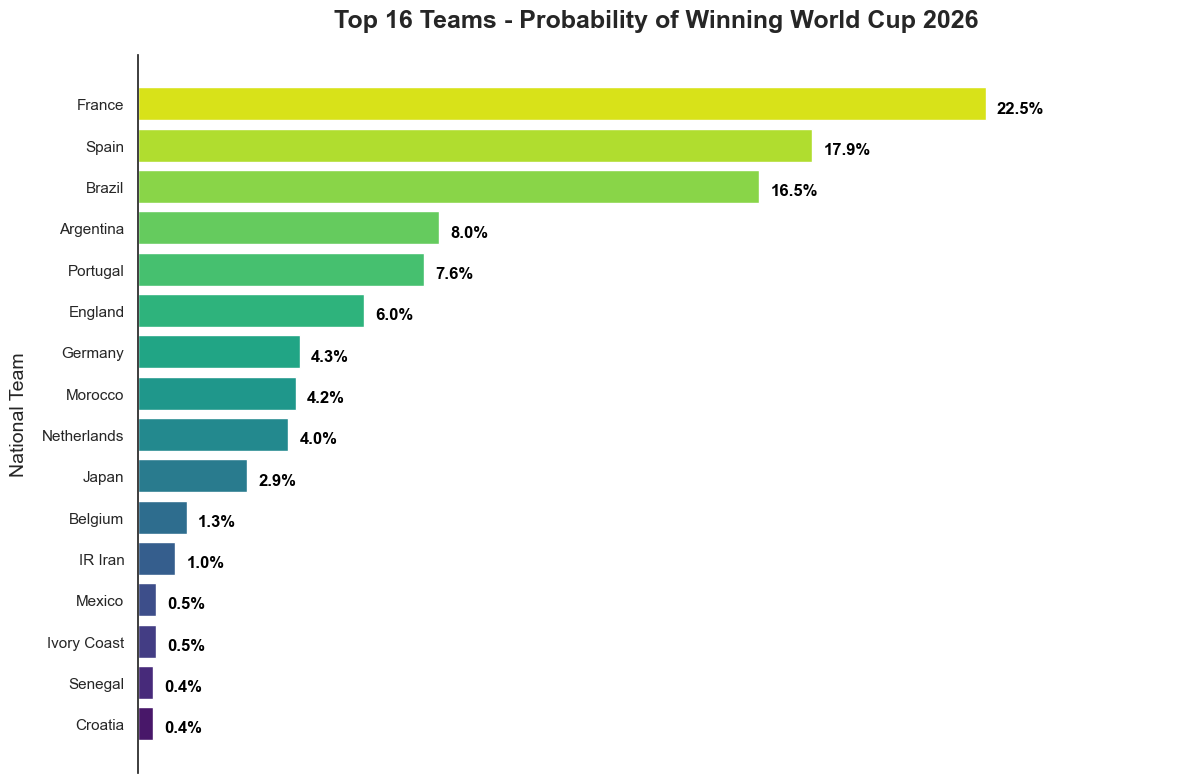

In [25]:
# Top 16 Teams - Probability of Winning World Cup 2026
# 1. Set the overall style of the chart (clean style without grid lines)
sns.set_theme(style="white")

# 2. Select the top 16 teams from the final predictions dataframe
top_16_teams = df_ko_results.head(16).copy()

# 3. Sort them in ascending order so the highest team appears at the top of the chart
top_16_teams = top_16_teams.sort_values('Champion', ascending=True)

# 4. Create the plot
plt.figure(figsize=(12, 8))

# Use a sleek color gradient (from dark blue to light green)
colors = sns.color_palette("viridis", len(top_16_teams))

# Draw the horizontal bars
bars = plt.barh(top_16_teams.index, top_16_teams['Champion'], color=colors)

# 5. Add the numbers (percentages) at the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2 - 0.1, 
             f'{bar.get_width()}%', 
             va='center', ha='left', fontsize=12, fontweight='bold', color='black')

# 6. Format titles and labels (Removed emojis to avoid font display warnings)
plt.title('Top 16 Teams - Probability of Winning World Cup 2026', 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel('National Team', fontsize=14, labelpad=10)
plt.xlabel('') # Removed x-axis label for a cleaner look

# Give extra space on the right so the numbers are fully visible
plt.xlim(0, top_16_teams['Champion'].max() + 5)

# Remove the top, right, and bottom borders for a minimalist, clean look
sns.despine(bottom=True)

# Hide the x-axis tick marks and numbers since we have data labels directly on the bars
plt.xticks([])

# 7. Display the chart
plt.tight_layout()
plt.show()

### Top-10-Must-Watch-Matches

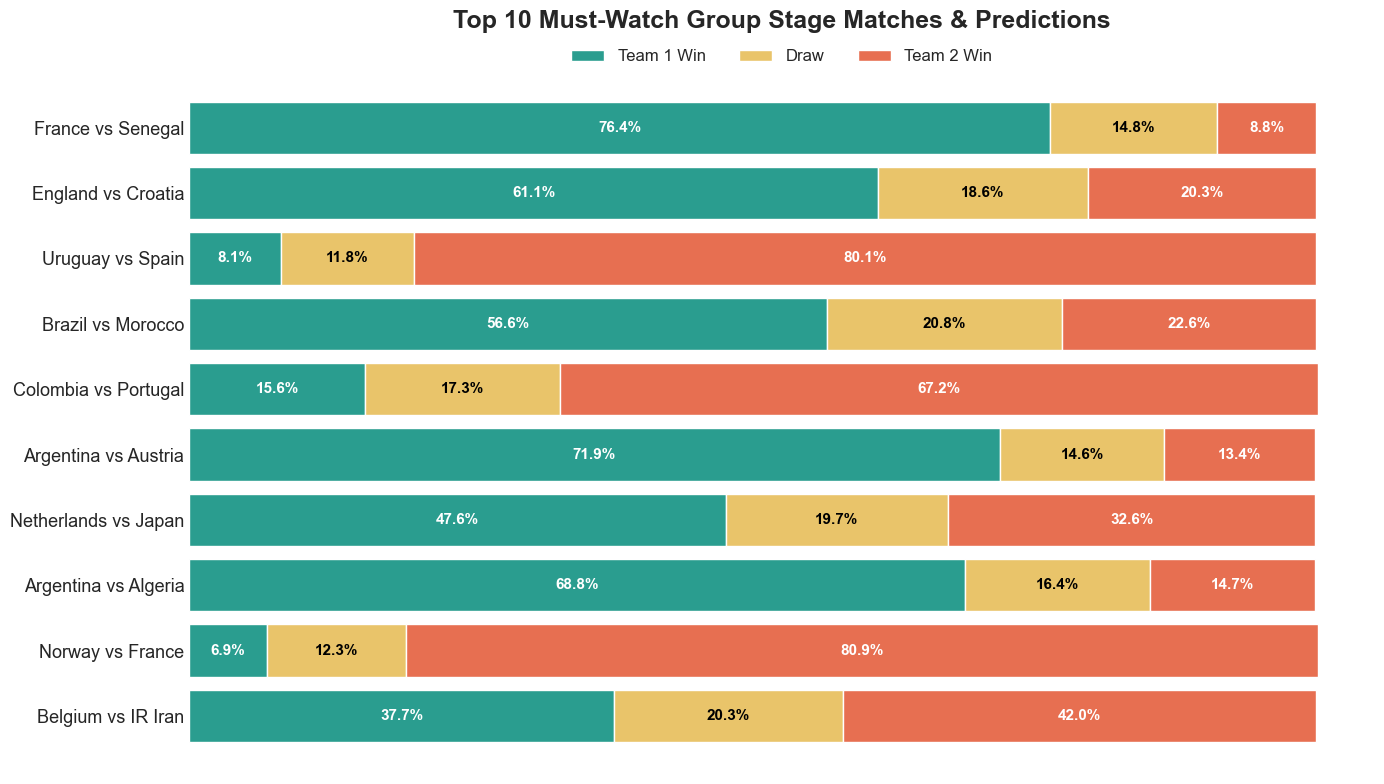

In [26]:
# 1. Re-create points_dict directly from df_teams to prevent NameError
points_dict = pd.Series(df_teams['Ranking Points'].values, index=df_teams['Team']).to_dict()

# 2. Function to calculate Match Excitement Score (Harmonic Mean)
def calculate_match_excitement(t1_points, t2_points):
    """
    Calculates how exciting a match is based on the strength and closeness of both teams.
    """
    if pd.isna(t1_points) or pd.isna(t2_points) or (t1_points + t2_points) == 0:
        return np.nan
    return round((2 * t1_points * t2_points) / (t1_points + t2_points), 1)

match_scores = []

# 3. Iterate through group stage matches only (assuming first 72 matches)
group_matches = df_matches_predicted[df_matches_predicted['Match No.'] <= 72]

for index, row in group_matches.iterrows():
    # Use the names directly without splitting
    t1_name = row['Team 1']
    t2_name = row['Team 2']
    
    if pd.notna(t1_name) and pd.notna(t2_name):
        # Safely fetch points from the newly created dictionary
        t1_pts = float(points_dict.get(t1_name, 1200))
        t2_pts = float(points_dict.get(t2_name, 1200))
        
        # Calculate excitement score
        excitement = calculate_match_excitement(t1_pts, t2_pts)
        
        match_scores.append({
            'Match_Label': f"{t1_name} vs {t2_name}",
            'Excitement_Score': excitement,
            'T1_Win': row['T1_Win_%'],
            'Draw': row['Draw_%'],
            'T2_Win': row['T2_Win_%']
        })

# 4. Create DataFrame and get the Top 10 most exciting matches
df_watchability = pd.DataFrame(match_scores)
df_top_10 = df_watchability.sort_values(by='Excitement_Score', ascending=False).head(10)

# Sort ascending for the horizontal bar chart (so the absolute best match is at the very top)
df_top_10 = df_top_10.sort_values(by='Excitement_Score', ascending=True)

# 5. Visualization: Stacked Bar Chart for Match Predictions
# Clean minimalist style without grid lines
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 8))

# Define an elegant color palette
color_t1 = '#2A9D8F'  # Teal/Green for Team 1
color_draw = '#E9C46A' # Sand/Yellow for Draw
color_t2 = '#E76F51'  # Terracotta/Red for Team 2

# Extract data for plotting
labels = df_top_10['Match_Label']
t1_wins = df_top_10['T1_Win']
draws = df_top_10['Draw']
t2_wins = df_top_10['T2_Win']

# Plot stacked horizontal bars
ax.barh(labels, t1_wins, color=color_t1, edgecolor='white', label='Team 1 Win')
ax.barh(labels, draws, left=t1_wins, color=color_draw, edgecolor='white', label='Draw')
ax.barh(labels, t2_wins, left=t1_wins + draws, color=color_t2, edgecolor='white', label='Team 2 Win')

# 6. Add percentage text directly inside the bars
for i, (idx, row) in enumerate(df_top_10.iterrows()):
    # Add Team 1 percentage
    if row['T1_Win'] > 6:
        ax.text(row['T1_Win']/2, i, f"{row['T1_Win']}%", 
                va='center', ha='center', color='white', fontweight='bold', fontsize=11)
        
    # Add Draw percentage
    if row['Draw'] > 6:
        ax.text(row['T1_Win'] + row['Draw']/2, i, f"{row['Draw']}%", 
                va='center', ha='center', color='black', fontweight='bold', fontsize=11)
        
    # Add Team 2 percentage
    if row['T2_Win'] > 6:
        ax.text(row['T1_Win'] + row['Draw'] + row['T2_Win']/2, i, f"{row['T2_Win']}%", 
                va='center', ha='center', color='white', fontweight='bold', fontsize=11)

# 7. Formatting the chart
ax.set_title('Top 10 Must-Watch Group Stage Matches & Predictions', 
             fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel('') 

# Clean up borders and axes
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', labelsize=13, length=0) 

# Place a clean legend above the chart
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False, fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()

### Most-Locked-Matches

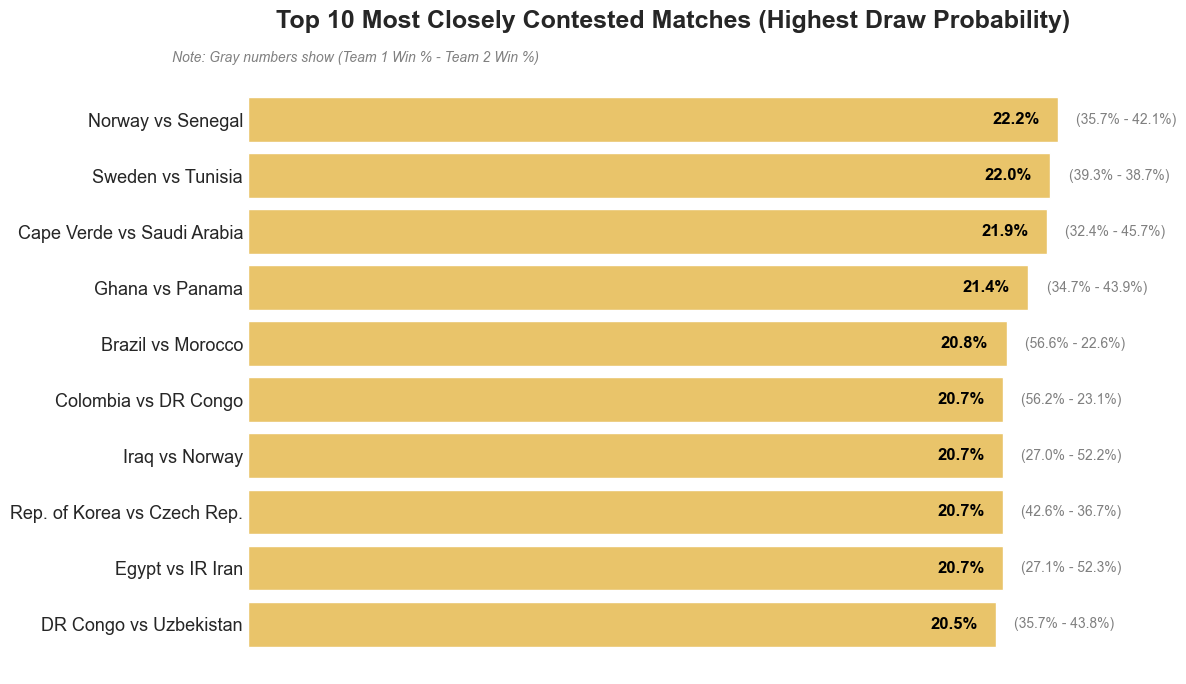

In [27]:
# Most Closely Contested Matches (Highest Draw Probability)
# 1. Filter group stage matches only (assuming first 72 matches)
group_matches = df_matches_predicted[df_matches_predicted['Match No.'] <= 72].copy()

# 2. Calculate the "Closeness" of the match
# We calculate the absolute difference between T1 Win % and T2 Win %
# A smaller difference means the match is highly contested (equally likely for both)
group_matches['Win_Diff'] = abs(group_matches['T1_Win_%'] - group_matches['T2_Win_%'])

# 3. Sort by the highest Draw % first, then by the smallest Win Difference
df_top_draws = group_matches.sort_values(by=['Draw_%', 'Win_Diff'], ascending=[False, True]).head(10)

# Sort ascending for the horizontal bar chart (so the highest draw % is at the very top)
df_top_draws = df_top_draws.sort_values(by='Draw_%', ascending=True)

# 4. Create the Match Label for the chart
df_top_draws['Match_Label'] = df_top_draws['Team 1'] + " vs " + df_top_draws['Team 2']

# 5. Visualization: Clean Bar Chart focusing on Draw Probability
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 7))

# Choose a subtle color for the draw bars (e.g., a nice slate gray or muted gold)
draw_color = '#E9C46A' 

bars = ax.barh(df_top_draws['Match_Label'], df_top_draws['Draw_%'], color=draw_color, edgecolor='white')

# 6. Add the percentage text and the win percentages for context
for i, bar in enumerate(bars):
    # The draw percentage
    width = bar.get_width()
    ax.text(width - 0.5, bar.get_y() + bar.get_height()/2, f"{width}%", 
            va='center', ha='right', color='black', fontweight='bold', fontsize=12)
    
    # Add context (T1 Win % vs T2 Win %) outside the bar for extra info
    t1_win = df_top_draws.iloc[i]['T1_Win_%']
    t2_win = df_top_draws.iloc[i]['T2_Win_%']
    context_text = f"({t1_win}% - {t2_win}%)"
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, context_text, 
            va='center', ha='left', color='gray', fontsize=10)

# 7. Formatting the chart
ax.set_title('Top 10 Most Closely Contested Matches (Highest Draw Probability)', 
             fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel('') 

# Clean up borders and axes
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', labelsize=13, length=0) 

# Add a small note explaining the gray numbers
plt.figtext(0.15, 0.9, "Note: Gray numbers show (Team 1 Win % - Team 2 Win %)", 
            fontsize=10, color='gray', style='italic')

# Display the chart
plt.tight_layout()
plt.show()

### Qualified-Teams-Power-Tiers

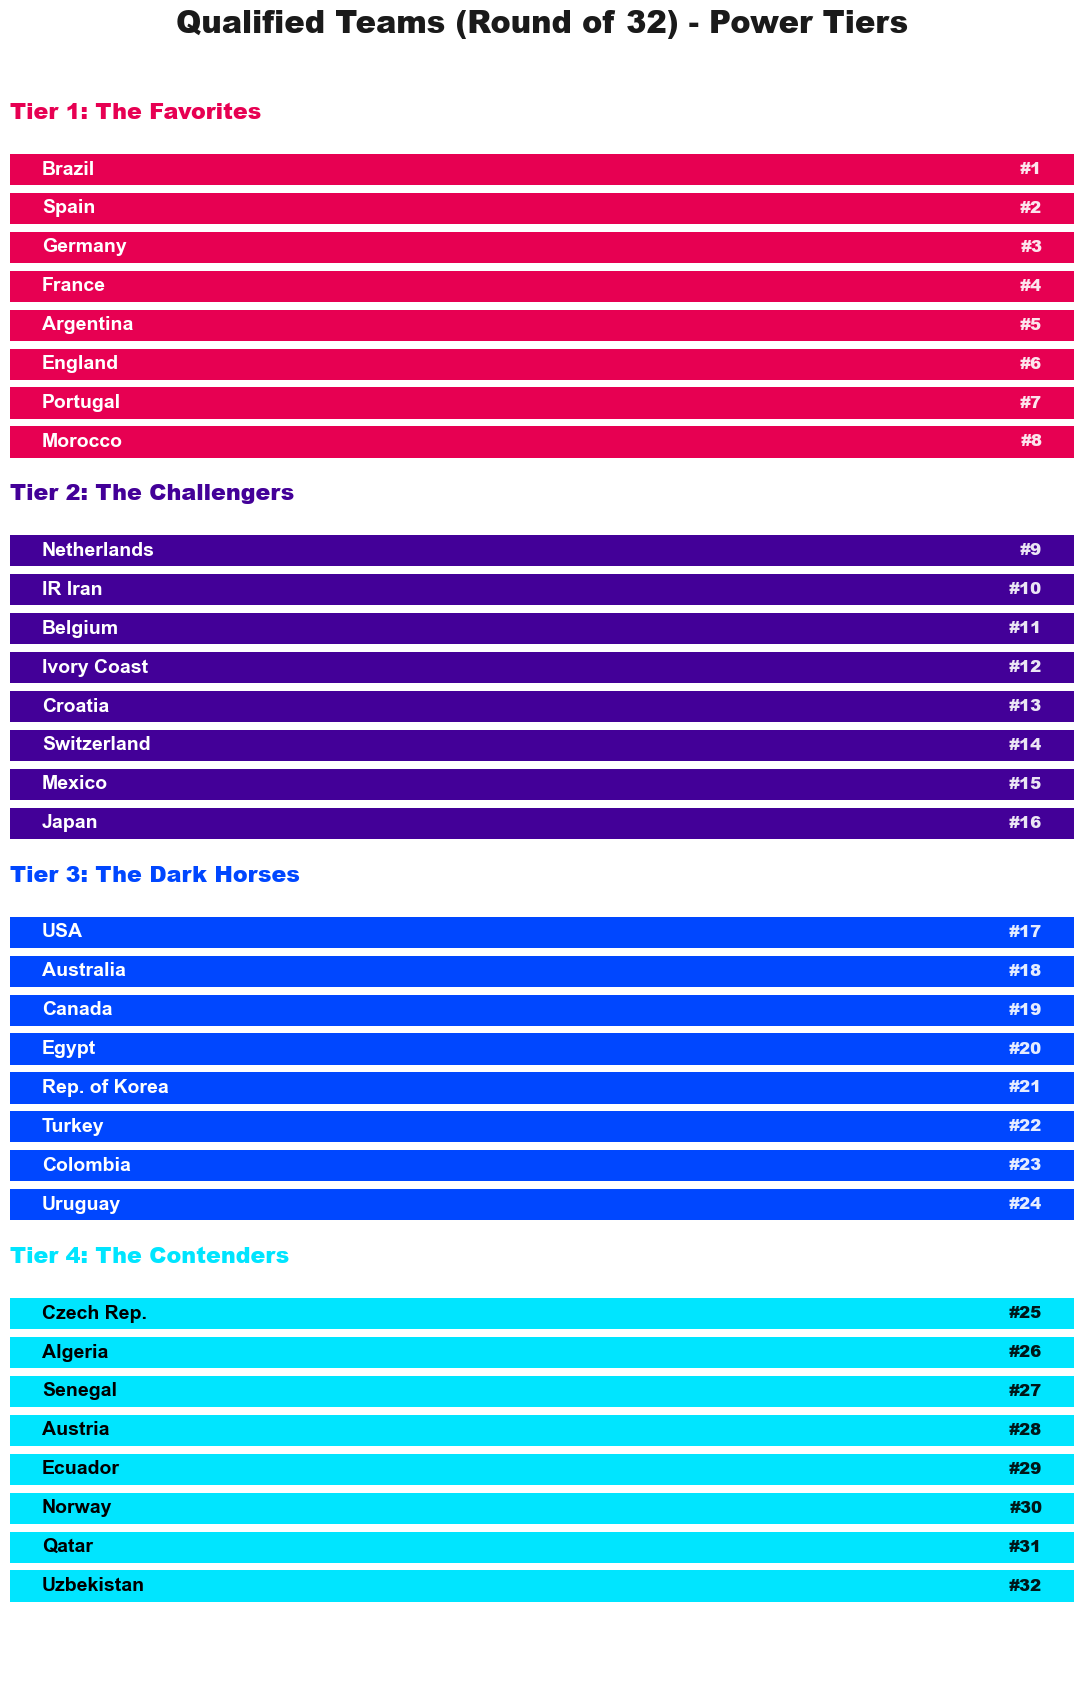

In [28]:
# Teams Most Likely to Advance to the Knockout Stage
# 1. Get Top 32 teams sorted by Total_Adv descending
top_32 = df_advancement.sort_values(by='Total_Adv', ascending=False).head(32).copy()
top_32 = top_32.reset_index().rename(columns={'index': 'Team'})

# 2. Assign Tier Names (8 teams per tier)
tier_names = [
    'Tier 1: The Favorites', 
    'Tier 2: The Challengers', 
    'Tier 3: The Dark Horses', 
    'Tier 4: The Contenders'
]
top_32['Tier'] = np.repeat(tier_names, 8)

# Reverse the dataframe so Tier 4 is plotted at the bottom and Tier 1 at the top
top_32 = top_32.iloc[::-1].reset_index(drop=True)

# 3. Calculate Y positions and Label positions to create visual gaps
y_positions = []
current_y = 0
tier_label_y = {}

for i in range(32):
    y_positions.append(current_y)
    current_y += 1
    
    # After every 8 teams, add a gap and save the position for the Tier Label
    if (i + 1) % 8 == 0:
        tier_name = top_32.iloc[i]['Tier']
        tier_label_y[tier_name] = current_y + 0.2
        current_y += 1.8  # Add space between tiers

top_32['y_pos'] = y_positions

# 4. Setup Plot (Clean and Minimalist)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(11, 17))

# 5. Define VIBRANT, MODERN colors for each tier (Sports Analytics Style)
tier_colors = {
    'Tier 1: The Favorites': '#E70052',   # Vivid Crimson/Neon Pink
    'Tier 2: The Challengers': '#430098', # Deep Electric Purple
    'Tier 3: The Dark Horses': '#0047FF', # Vibrant Electric Blue
    'Tier 4: The Contenders': '#00E5FF'   # Bright Neon Cyan
}
colors = top_32['Tier'].map(tier_colors)

# 6. Plot bars with a uniform width of 1 (acting as a background for text)
bars = ax.barh(top_32['y_pos'], [1]*32, color=colors, height=0.8, edgecolor='none')

# 7. Add texts (Team Name & Rank) inside the bars
for i, bar in enumerate(bars):
    team = top_32.iloc[i]['Team']
    tier = top_32.iloc[i]['Tier']
    
    # Use Black text for the bright Cyan tier, White for the darker vibrant colors
    text_color = 'black' if tier == 'Tier 4: The Contenders' else 'white'
        
    # Add Team Name on the left
    ax.text(0.03, bar.get_y() + bar.get_height()/2, team, 
            va='center', ha='left', color=text_color, fontweight='bold', fontsize=14)
            
    # Add Rank Number on the right
    rank = 32 - i
    ax.text(0.97, bar.get_y() + bar.get_height()/2, f"#{rank}", 
            va='center', ha='right', color=text_color, fontweight='heavy', fontsize=12, alpha=0.9)

# 8. Add Tier Headers above each group
for tier, y_loc in tier_label_y.items():
    ax.text(0, y_loc, tier, va='bottom', ha='left', 
            color=tier_colors[tier], fontweight='black', fontsize=16)

# 9. Clean up formatting
ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)
ax.set_xlim(0, 1)

plt.title('Qualified Teams (Round of 32) - Power Tiers', 
          fontsize=22, fontweight='black', pad=35, loc='center', color='#1A1A1A')

plt.tight_layout()
plt.show()